# Feature Selection GAS

In [1]:
stock_code = "GAS"

In [2]:
stock_code = str.lower(stock_code)

## Import libraries

In [3]:
import os
import sys
import pandas as pd


# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [4]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [5]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [6]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [7]:
output_column_name = "close"

In [8]:
train_ratio = DEFAULT_TRAIN_RATIO
input_window_size = DEFAULT_INPUT_WINDOW_SIZE
forecast_horizon_size = DEFAULT_FORECAST_HORIZON_SIZE

## Load data

In [9]:
df = pd.read_csv(f"../../unified_dataframe/unified_{stock_code}.csv")

In [10]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,0,3,1,2,5.000000e-01,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,0,4,1,2,5.000000e-01,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,0,4,1,2,5.000000e-01,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,0,4,1,2,5.000000e-01,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,0,4,1,2,5.000000e-01,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0,3,1,3,1.224647e-16,-1.000000,-0.433884,-0.900969,0.196673,-0.980469
3265,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0,4,1,3,1.224647e-16,-1.000000,0.000000,1.000000,0.145799,-0.989314
3266,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0,4,1,3,1.224647e-16,-1.000000,0.974928,-0.222521,0.111659,-0.993747
3267,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0,4,1,3,1.224647e-16,-1.000000,0.433884,-0.900969,0.094537,-0.995521


In [11]:
# Sort by date or time index if available
if "date" in df.columns:
    df = df.sort_values("date").reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

# --- Adjusted split index logic ---
split_index = ceil(len(df) * train_ratio)
split_index -= input_window_size  # ensure full input window fits

# Make split_index divisible by forecast_horizon_size
remainder = split_index % forecast_horizon_size
if remainder != 0:
    split_index -= remainder

# Guard against invalid split index
if split_index <= 0 or split_index >= len(df):
    raise ValueError(
        f"Adjusted split_index ({split_index}) is invalid for data length {len(df)}"
    )

# Add back input windwo size to split_index
split_index += input_window_size
split_index = int(split_index)
split_index

2940

In [12]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [13]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,0,3,1,2,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,0,4,1,2,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,0,4,1,2,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,0,4,1,2,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,0,4,1,2,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,2024-02-26,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,...,0,4,1,1,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,2024-02-27,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,...,0,4,1,1,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,2024-02-28,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,...,0,4,1,1,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,2024-02-29,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,...,0,5,1,1,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


In [14]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2024-03-04,5.974505,92.653983,563.353548,615.483871,41.935484,219.354839,228.387097,206.451613,1916.129032,...,0,1,1,2,1.000000e+00,6.123234e-17,0.000000,1.000000,0.891981,0.452072
1,2024-03-05,5.962857,92.666454,566.691935,619.354839,42.419355,224.193548,235.483871,208.064516,1945.161290,...,0,1,1,2,1.000000e+00,6.123234e-17,0.781831,0.623490,0.899631,0.436651
2,2024-03-06,5.951209,92.678924,570.030323,623.225806,42.903226,229.032258,242.580645,209.677419,1974.193548,...,0,1,1,2,1.000000e+00,6.123234e-17,0.974928,-0.222521,0.907014,0.421101
3,2024-03-07,5.939560,92.691394,573.368710,627.096774,43.387097,233.870968,249.677419,211.290323,2003.225806,...,0,1,1,2,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.914128,0.405426
4,2024-03-08,5.927912,92.703864,576.707097,630.967742,43.870968,238.709677,256.774194,212.903226,2032.258065,...,0,2,1,2,1.000000e+00,6.123234e-17,-0.433884,-0.900969,0.920971,0.389630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,2025-06-24,7.892088,106.580000,924.416000,588.792000,71.022000,298.416000,222.118000,228.012000,2728.292000,...,0,4,1,3,1.224647e-16,-1.000000e+00,0.781831,0.623490,0.128748,-0.991677
325,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0,4,1,3,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.111659,-0.993747
326,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0,4,1,3,1.224647e-16,-1.000000e+00,0.433884,-0.900969,0.094537,-0.995521
327,2025-06-27,7.926044,106.290000,915.328000,595.866000,69.641000,285.543000,221.559000,230.326000,2696.421000,...,0,4,1,3,1.224647e-16,-1.000000e+00,-0.433884,-0.900969,0.077386,-0.997001


In [15]:
train = train.drop(columns=["date"])

In [16]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,0,4,1,1,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,0,4,1,1,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,0,4,1,1,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,0,5,1,1,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


## Feature Selection

In [17]:
feature_columns = train.columns.tolist()
feature_columns.remove(output_column_name)
len(feature_columns)

221

In [18]:
my_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    dataframe=train,
    feature_columns=feature_columns,
    target_column=output_column_name,
)

## Feature Selection Fit

In [19]:
my_feature_selector.fit()

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.451e+02, tolerance: 1.189e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...
Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...


## Feature Selection Type: XGB_REGRESSOR

In [20]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

,feature,importance
0,low,1.000000
1,high,0.601406
2,vn_index_close,0.015000
3,vn_30_index_close,0.007250
4,dow_jones_close,0.002733
...,...,...
216,mip_cement,0.000000
217,mip_chemical_fertilizers,0.000000
218,mip_crude_oil_extraction,0.000000
219,mip_domestic_ceramics,0.000000


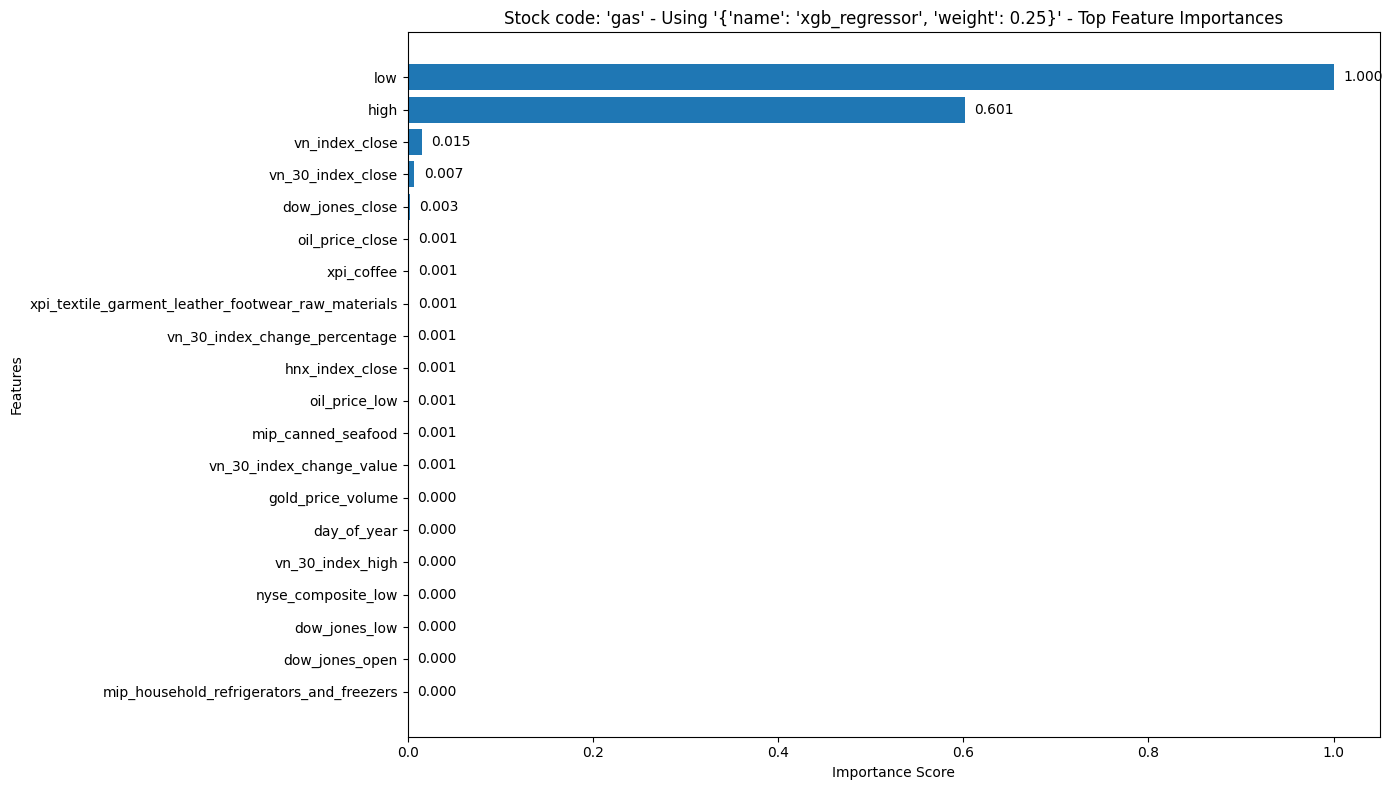

In [21]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

## Feature Selection Type: LASSO

In [22]:
my_feature_selector.get_feature_importance(FeatureSelectorType.LASSO)

,feature,importance
0,high,1.000000
1,open,0.213204
2,low,0.184853
3,vn_30_index_change_value,0.021767
4,mip_fired_tiles,0.002533
...,...,...
216,mip_crude_oil_extraction,0.000000
217,mip_domestic_ceramics,0.000000
218,mip_extracted_stone,0.000000
219,mip_fabric,0.000000


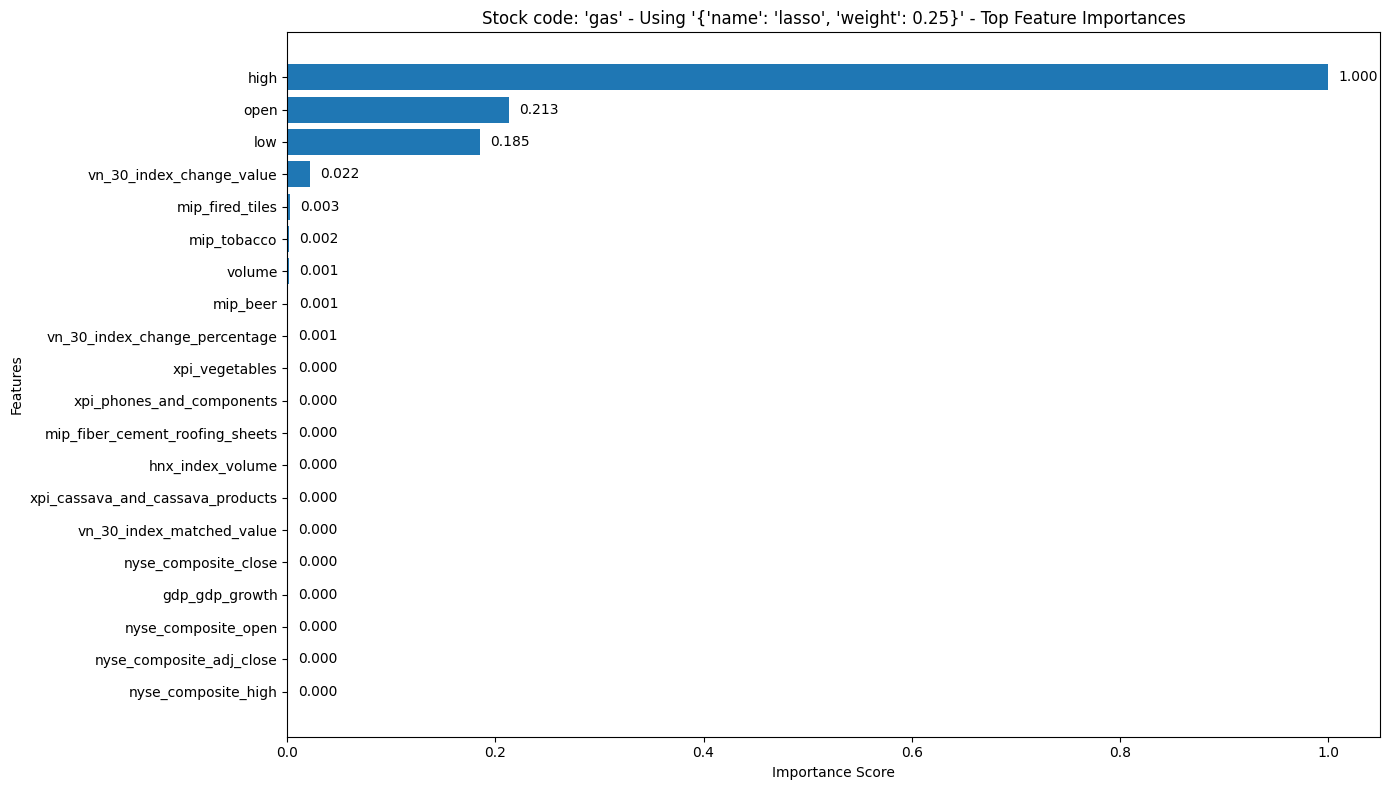

In [23]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.LASSO)

## Feature Selection Type: ELASTIC_NET

In [24]:
my_feature_selector.get_feature_importance(FeatureSelectorType.ELASTIC_NET)

,feature,importance
0,high,1.000000
1,low,0.967881
2,open,0.887963
3,vn_index_close,0.071138
4,mip_canned_seafood,0.061197
...,...,...
216,mip_generated_electricity,0.000000
217,mip_granulated_sugar,0.000000
218,mip_gravel_and_pebbles,0.000000
219,mip_household_electric_fans,0.000000


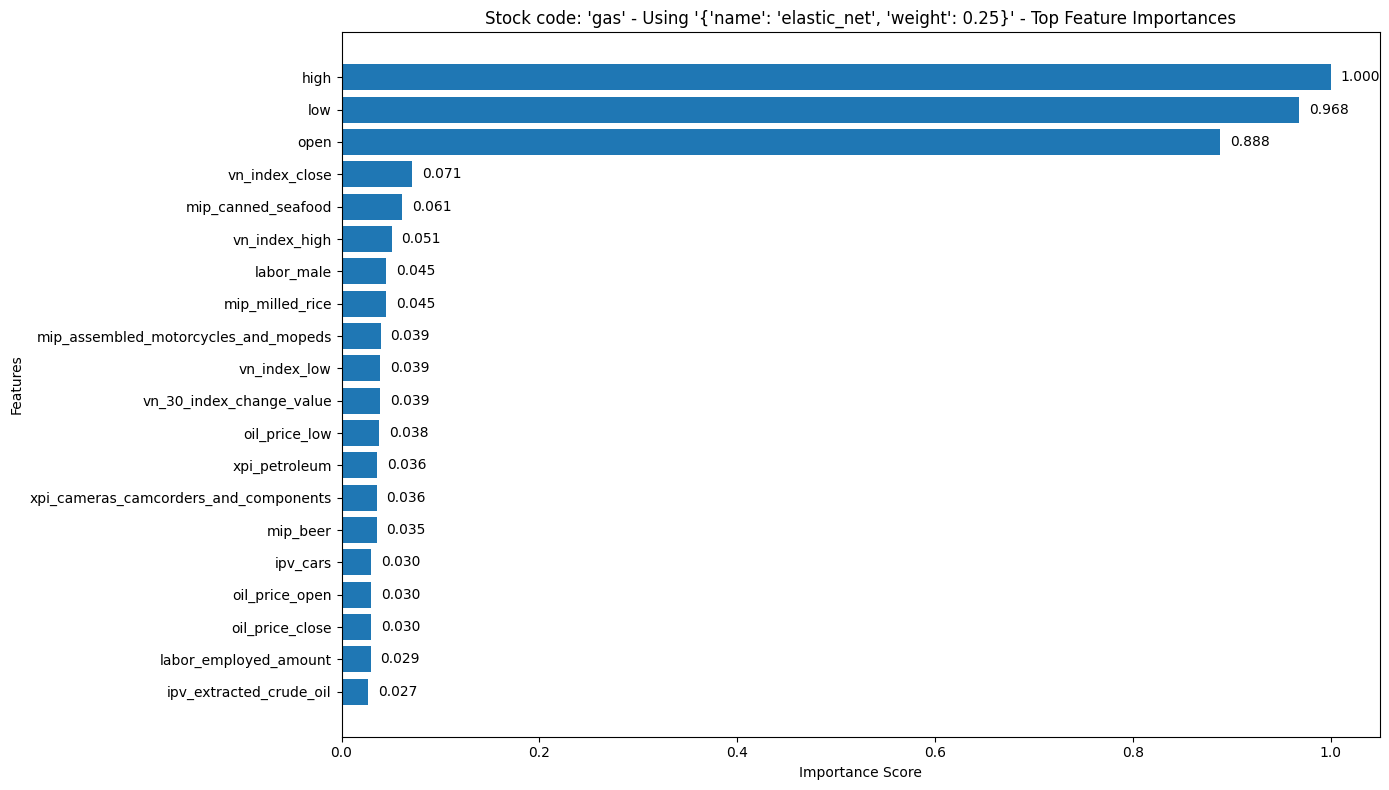

In [25]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.ELASTIC_NET)

## Feature Selection Type: XGB_SHAP

In [26]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_SHAP)

,feature,importance
0,low,1.000000
1,high,0.925642
2,vn_index_close,0.009398
3,vn_30_index_change_value,0.008949
4,vn_30_index_change_percentage,0.008782
...,...,...
216,mip_chemical_fertilizers,0.000000
217,mip_crude_oil_extraction,0.000000
218,mip_domestic_ceramics,0.000000
219,mip_fabric,0.000000


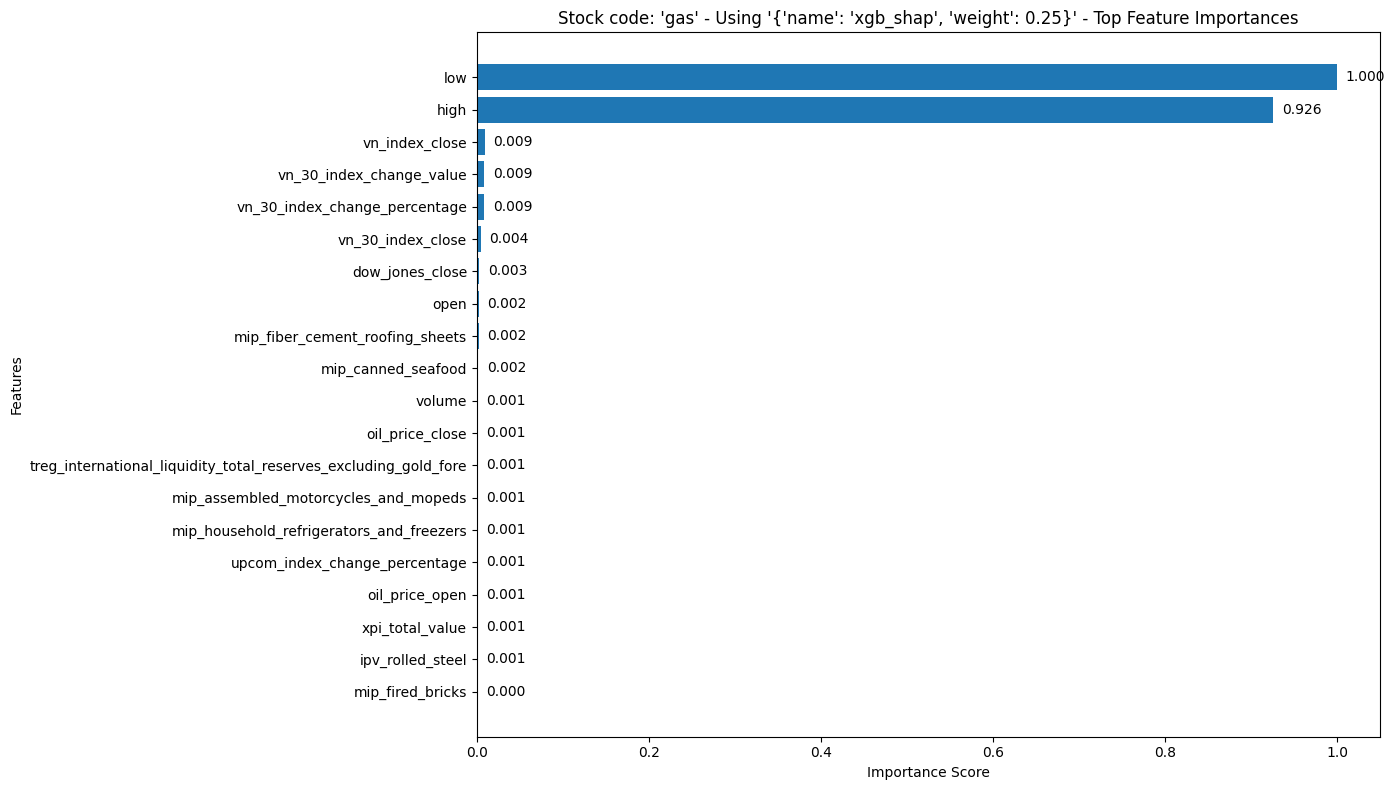

In [27]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_SHAP)

## Summrarize Feature Importance

In [28]:
my_feature_selector.get_feature_importance()

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,high,0.601406,1.000000,1.000000,0.925642,0.150352,0.250000,0.250000,0.231410,0.881762
1,low,1.000000,0.184853,0.967881,1.000000,0.250000,0.046213,0.241970,0.250000,0.788183
2,open,0.000340,0.213204,0.887963,0.002445,0.000085,0.053301,0.221991,0.000611,0.275988
3,vn_index_close,0.015000,0.000000,0.071138,0.009398,0.003750,0.000000,0.017785,0.002350,0.023884
4,vn_30_index_change_value,0.000601,0.021767,0.039245,0.008949,0.000150,0.005442,0.009811,0.002237,0.017641
...,...,...,...,...,...,...,...,...,...,...
216,mip_refined_vegetable_oil,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
217,mip_processed_tea,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
218,mip_printed_newspapers_and_other_printing_prod...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
219,mip_pesticides,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\gas_final_feature_importances.png


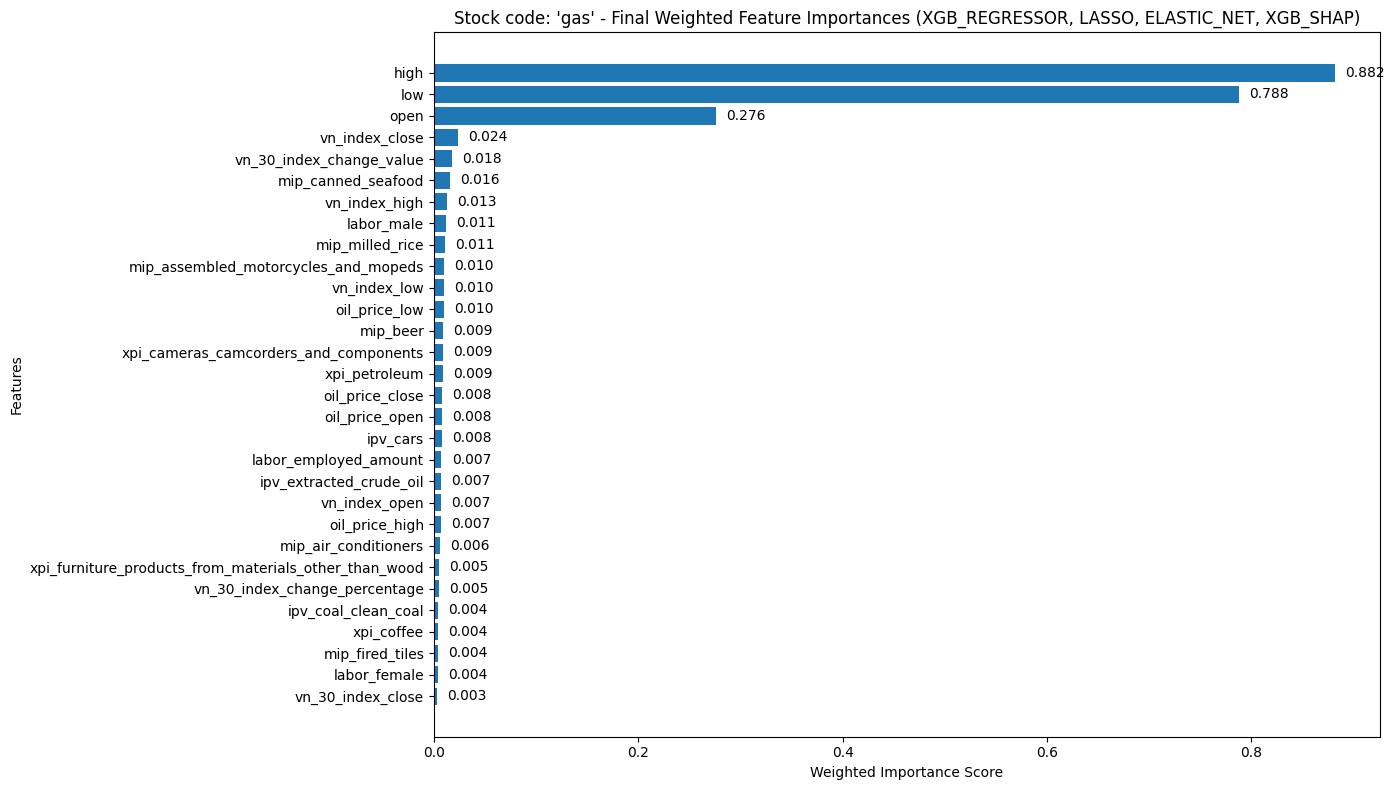

In [29]:
important_features_df = my_feature_selector.plot_final_feature_importances(
    stock_code=stock_code,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [45]:
important_features_df = my_feature_selector.get_important_features_df(
    top_n=TOP_N_FEATURES,
)

In [46]:
important_features_df

,feature,final_importance
21,high,0.881762
49,low,0.788183
131,open,0.275988
168,vn_index_close,0.023884
159,vn_30_index_change_value,0.017641
57,mip_canned_seafood,0.015895
169,vn_index_high,0.012719
46,labor_male,0.011390
81,mip_milled_rice,0.011257
53,mip_assembled_motorcycles_and_mopeds,0.010104


In [47]:
important_features_df.to_csv(f"important_features_df_fs.csv", index=False)

In [48]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['high',
 'low',
 'open',
 'vn_index_close',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'vn_index_high',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'vn_index_low',
 'oil_price_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'xpi_petroleum',
 'oil_price_close',
 'oil_price_open',
 'ipv_cars',
 'labor_employed_amount',
 'ipv_extracted_crude_oil',
 'vn_index_open',
 'oil_price_high',
 'mip_air_conditioners',
 'xpi_furniture_products_from_materials_other_than_wood',
 'vn_30_index_change_percentage',
 'ipv_coal_clean_coal',
 'xpi_coffee',
 'mip_fired_tiles',
 'labor_female',
 'vn_30_index_close',
 'volume',
 'mip_light_bulbs',
 'ipv_processed_seafood',
 'xpi_pepper',
 'xpi_cassava_and_cassava_products',
 'rrrr_refinancing_rate',
 'upcom_index_high',
 'dow_jones_close',
 'season',
 'vn_30_index_negotiated_volume']

## Heatmap Visualization

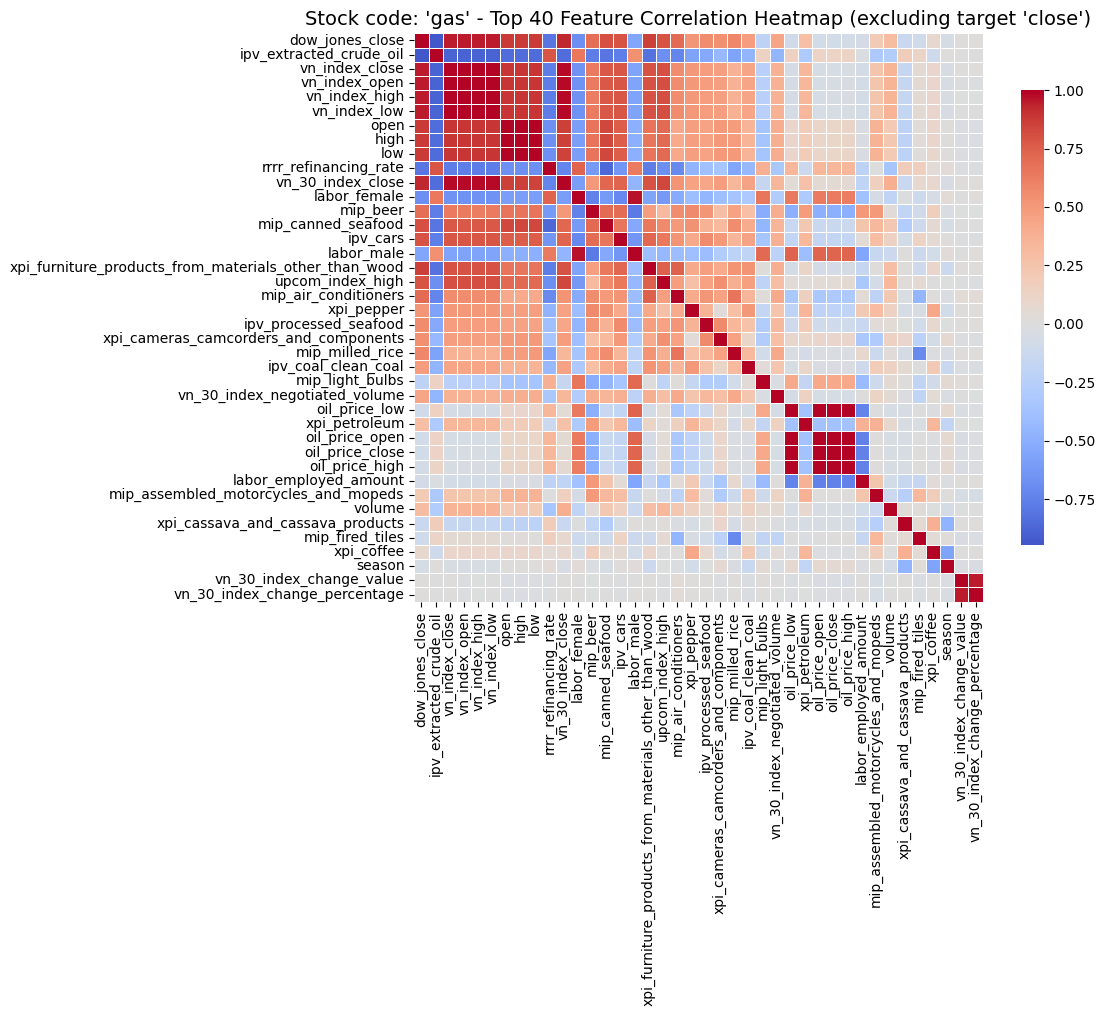

In [49]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [50]:
correlation_df = my_feature_selector.get_feature_correlation_df(
    important_features_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [51]:
correlation_df

,feature_1,feature_2,corr
0,vn_index_open,vn_index_high,0.999816
1,vn_index_close,vn_index_low,0.999729
2,vn_index_close,vn_index_high,0.999705
3,vn_index_open,vn_index_low,0.999698
4,vn_index_high,vn_index_low,0.999616
5,vn_index_close,vn_index_open,0.999446
6,open,low,0.999335
7,open,high,0.999255
8,oil_price_low,oil_price_close,0.999254
9,oil_price_open,oil_price_high,0.999171


In [52]:
kept_features, dropped_features, pruned_importance_df = (
    my_feature_selector.drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 14 highly correlated features (|r| >= 0.85):
['dow_jones_close', 'labor_female', 'low', 'oil_price_close', 'oil_price_high', 'oil_price_open', 'open', 'rrrr_refinancing_rate', 'vn_30_index_change_percentage', 'vn_30_index_close', 'vn_index_close', 'vn_index_high', 'vn_index_low', 'vn_index_open']
✅ Kept 26 features after pruning correlation redundancy.


In [53]:
kept_features

['high',
 'vn_30_index_change_value',
 'mip_canned_seafood',
 'labor_male',
 'mip_milled_rice',
 'mip_assembled_motorcycles_and_mopeds',
 'oil_price_low',
 'mip_beer',
 'xpi_cameras_camcorders_and_components',
 'xpi_petroleum',
 'ipv_cars',
 'labor_employed_amount',
 'ipv_extracted_crude_oil',
 'mip_air_conditioners',
 'xpi_furniture_products_from_materials_other_than_wood',
 'ipv_coal_clean_coal',
 'xpi_coffee',
 'mip_fired_tiles',
 'volume',
 'mip_light_bulbs',
 'ipv_processed_seafood',
 'xpi_pepper',
 'xpi_cassava_and_cassava_products',
 'upcom_index_high',
 'season',
 'vn_30_index_negotiated_volume']

In [54]:
dropped_features

['dow_jones_close',
 'labor_female',
 'low',
 'oil_price_close',
 'oil_price_high',
 'oil_price_open',
 'open',
 'rrrr_refinancing_rate',
 'vn_30_index_change_percentage',
 'vn_30_index_close',
 'vn_index_close',
 'vn_index_high',
 'vn_index_low',
 'vn_index_open']

## Number of features dropped

In [55]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 14 features


In [56]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,0,4,1,1,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,0,4,1,1,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,0,4,1,1,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,0,5,1,1,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371


## Heatmap Visualization before + after feature selection

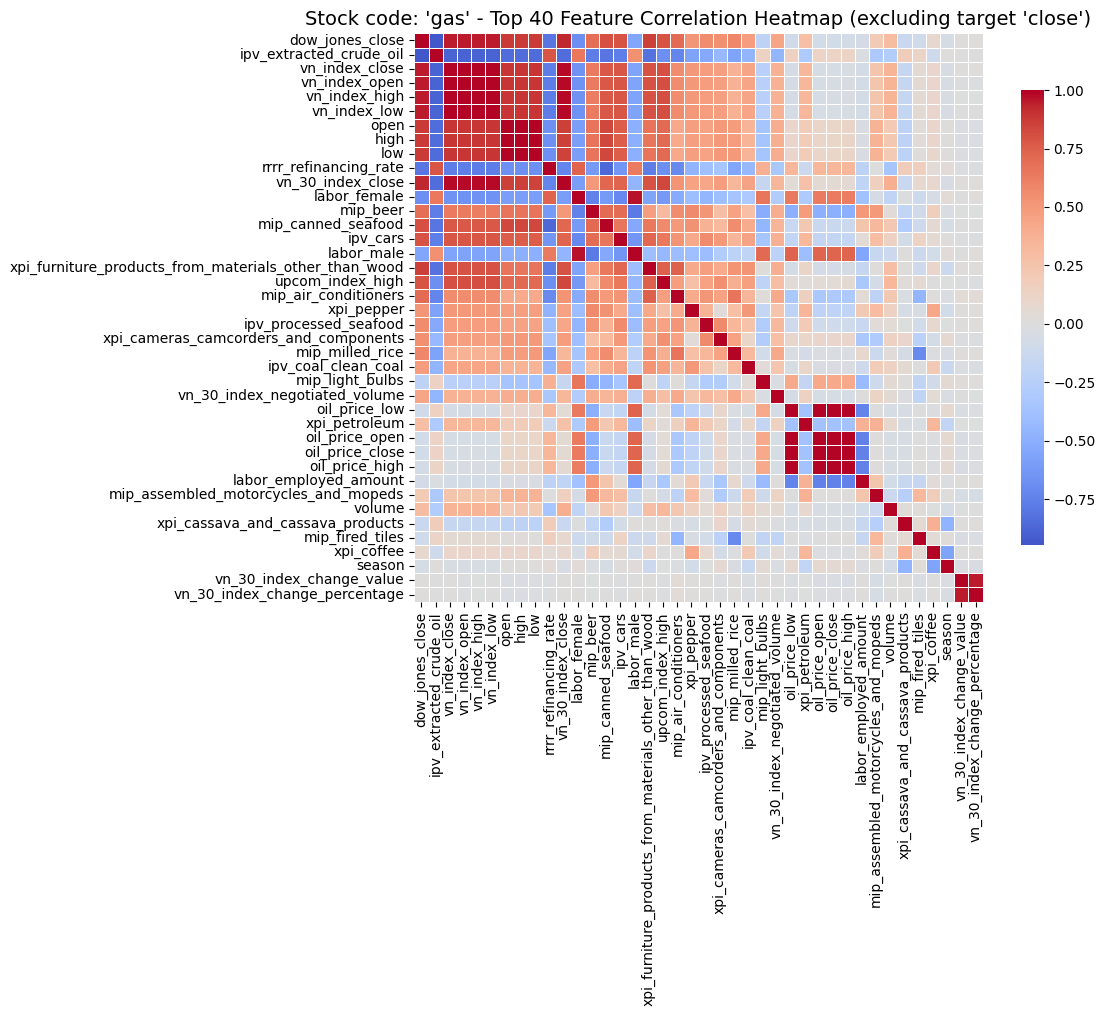

In [57]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

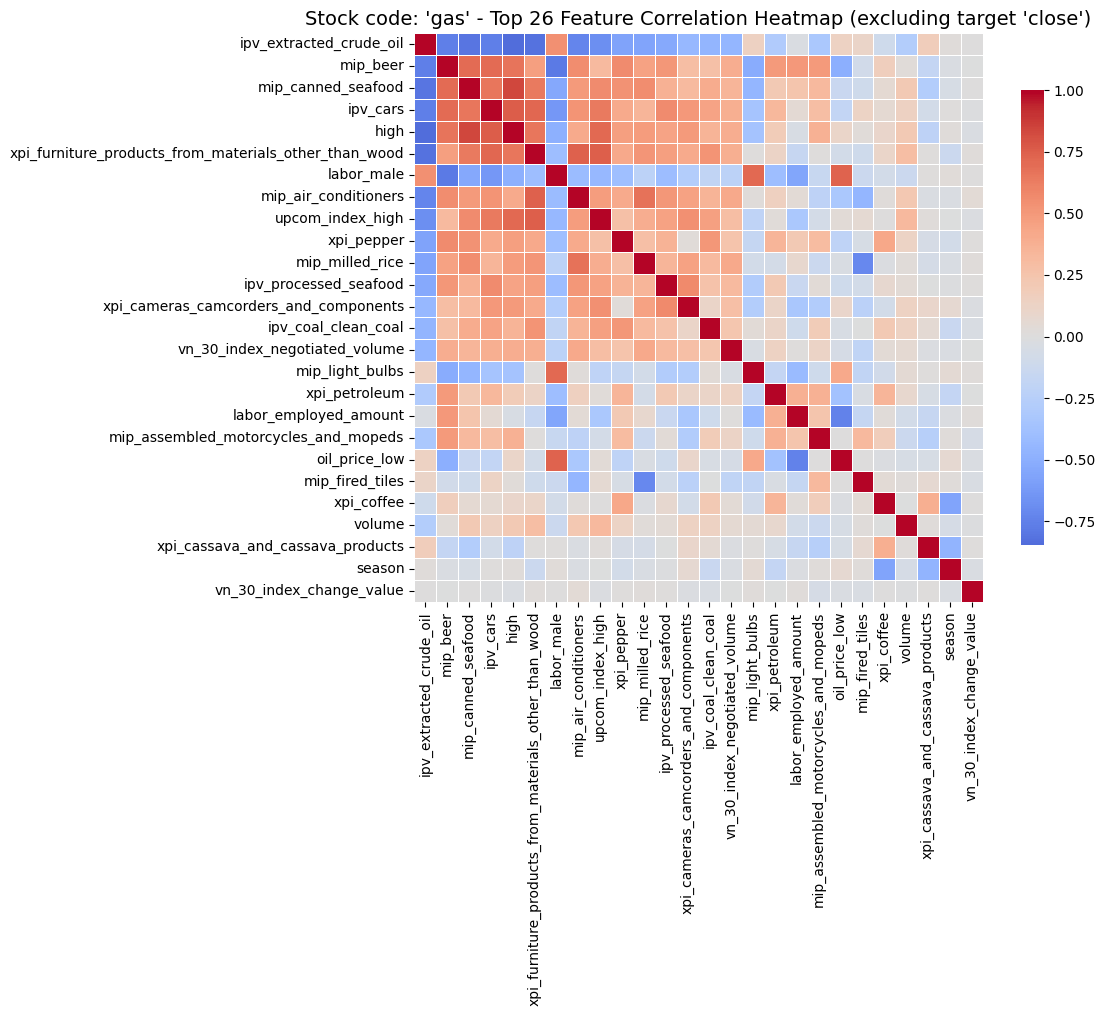

In [58]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=kept_features,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [59]:
feature_selected_train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,192.136129,...,0,3,1,2,0.500000,-8.660254e-01,0.000000,1.000000,0.642055,-0.766659
1,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,193.274516,...,0,4,1,2,0.500000,-8.660254e-01,0.781831,0.623490,0.628763,-0.777597
2,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,194.412903,...,0,4,1,2,0.500000,-8.660254e-01,0.974928,-0.222521,0.615285,-0.788305
3,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,195.551290,...,0,4,1,2,0.500000,-8.660254e-01,0.433884,-0.900969,0.601624,-0.798779
4,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,196.689677,...,0,4,1,2,0.500000,-8.660254e-01,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,165.172414,...,0,4,1,1,0.866025,5.000000e-01,0.000000,1.000000,0.831171,0.556017
2936,6.044396,92.579162,562.413793,620.689655,42.068966,227.586207,204.137931,202.758621,1882.758621,163.448276,...,0,4,1,1,0.866025,5.000000e-01,0.781831,0.623490,0.840618,0.541628
2937,6.032747,92.591632,556.206897,610.344828,41.034483,213.793103,202.068966,201.379310,1841.379310,161.724138,...,0,4,1,1,0.866025,5.000000e-01,0.974928,-0.222521,0.849817,0.527078
2938,6.021099,92.604102,550.000000,600.000000,40.000000,200.000000,200.000000,200.000000,1800.000000,160.000000,...,0,5,1,1,0.866025,5.000000e-01,0.433884,-0.900969,0.858764,0.512371
